Number of Good Matches: 1


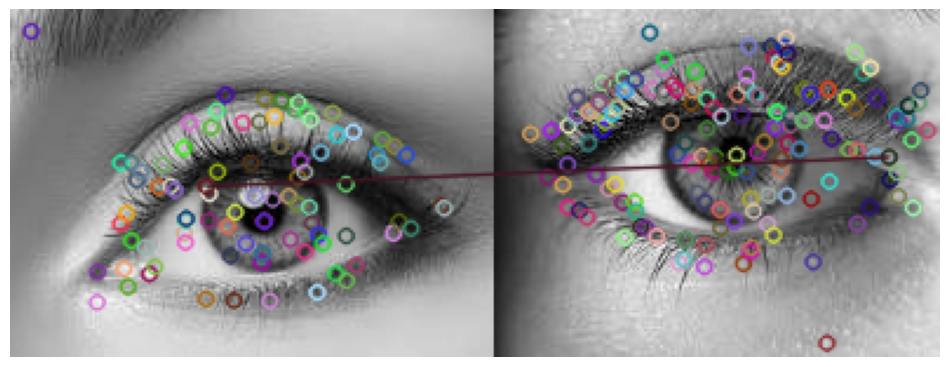

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1 = cv2.imread("/content/E1.jpeg", 0)  # Original
img2 = cv2.imread("/content/E2.jpeg", 0)  # Scaled or Rotated

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# BFMatcher
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Apply ratio test
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("Number of Good Matches:", len(good))

# Draw matches
img_match = cv2.drawMatches(img1, kp1, img2, kp2, good, None)

plt.figure(figsize=(12,6))
plt.imshow(img_match)
plt.axis('off')
plt.show()
